# Regression Analysis Practice Exercises

This notebook contains homework problems and practice code applying regression concepts:
*   Analyzing price column correlations with household attributes (bedrooms, bathrooms, sqft, year built).
*   Predicting student marks based on study time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("data.csv")

In [16]:
df.head(1)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA


In [32]:
df.drop(columns=['street','city','statezip','country'],inplace=True)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4600 non-null   float64
 1   bedrooms       4600 non-null   float64
 2   bathrooms      4600 non-null   float64
 3   sqft_living    4600 non-null   int64  
 4   sqft_lot       4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   waterfront     4600 non-null   int64  
 7   view           4600 non-null   int64  
 8   condition      4600 non-null   int64  
 9   sqft_above     4600 non-null   int64  
 10  sqft_basement  4600 non-null   int64  
 11  yr_built       4600 non-null   int64  
 12  yr_renovated   4600 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 467.3 KB


In [34]:
df.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774
bedrooms,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082
bathrooms,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886
sqft_living,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817
sqft_lot,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730
floors,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996
waterfront,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625
view,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967
condition,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818
sqft_above,0.367570,0.484705,0.689918,0.876443,0.216455,0.522814,0.078911,0.174327,-0.178196,1.000000,-0.038723,0.408535,-0.160426


In [49]:
new_df=df[['bedrooms','bathrooms','floors','sqft_living','yr_built','price']]

In [50]:
new_df.head()

,bedrooms,bathrooms,floors,sqft_living,yr_built,price
0,3.0,1.50,1.5,1340,1955,313000.0
1,5.0,2.50,2.0,3650,1921,2384000.0
2,3.0,2.00,1.0,1930,1966,342000.0
3,3.0,2.25,1.0,2000,1963,420000.0
4,4.0,2.50,1.0,1940,1976,550000.0


In [55]:
new_df['price']=new_df['price'].astype(int)

C:\Users\Aditya Sarapure\AppData\Local\Temp\ipykernel_8032\2555033536.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['price']=new_df['price'].astype(int)


In [56]:
new_df.corr()

,bedrooms,bathrooms,floors,sqft_living,yr_built,price
bedrooms,1.000000,0.545920,0.177895,0.594884,0.142461,0.200336
bathrooms,0.545920,1.000000,0.486428,0.761154,0.463498,0.327110
floors,0.177895,0.486428,1.000000,0.344850,0.467481,0.151461
sqft_living,0.594884,0.761154,0.344850,1.000000,0.287775,0.430410
yr_built,0.142461,0.463498,0.467481,0.287775,1.000000,0.021857
price,0.200336,0.327110,0.151461,0.430410,0.021857,1.000000


# Price Column :
* moderate co-relation with bathrooms,sqft_living
* low with bedrooms ,floors,yr_built

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [63]:
model=LinearRegression()

In [94]:
x=new_df[['sqft_living']]
y=new_df['price']

In [206]:
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [96]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
slope=model.coef_
intercept=model.intercept_
print("Model co-efficient:", slope)
print("Model Intercept:",intercept)

Model co-efficient: [267.22366232]
Model Intercept: -26048.231779844384


In [106]:
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [107]:
error=y_train-y_pred_train
print(error)

1898    -29161.312837
1370   -111023.792038
3038    -49850.259330
2361    434136.872644
156      52600.907147
            ...      
4426     -6767.689754
466     227644.602742
3092      8741.020116
3772    382874.699072
860     102884.974928
Name: price, Length: 3680, dtype: float64


In [108]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [120]:
r_square_seendata=r2_score(y_train,y_pred_train)
# print("R square value:",r_square_seendata)

In [121]:
r_square_unseendata=r2_score(y_test,y_pred_test)
print(f" R square value TEST:{r_square_unseendata}\n R square value TRAIN:{r_square_seendata}")

 R square value TEST:0.02906541017523301
 R square value TRAIN:0.461811232432354


In [122]:
MAE_train=mean_absolute_error(y_train,y_pred_train)
MAE_test=mean_absolute_error(y_test,y_pred_test)
print(f" MAE Train:{MAE_train}\n MAE Test:{MAE_test}")

 MAE Train:177772.49183719937
 MAE Test:225375.259150663


In [123]:
Mse_train=mean_squared_error(y_train,y_pred_train)
Mse_test=mean_squared_error(y_test,y_pred_test)

print(f" MSE Train:{Mse_train}\n MSE Test:{Mse_test}")


 MSE Train:76469034862.33504
 MSE Test:990204091595.672


In [124]:
# RMSE
Rmse_test=np.sqrt(Mse_test)
Rmse_train=np.sqrt(Mse_train)
print(f" RMSE_Train:{Rmse_train}\n RMSE_test:{Rmse_test}")

 RMSE_Train:276530.35070735915
 RMSE_test:995089.9917071179


# Trying with New Dataset

In [195]:
marks_df=pd.read_csv("Student_Marks.csv")




In [196]:
marks_df.columns

Index(['number_courses', 'time_study', 'Marks'], dtype='object')

In [197]:
marks_df.shape

(100, 3)

In [198]:
marks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [199]:
marks_df=marks_df.select_dtypes(include='number')

In [200]:
marks_df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [201]:
marks_df.corr()

,number_courses,time_study,Marks
number_courses,1.000000,0.204844,0.417335
time_study,0.204844,1.000000,0.942254
Marks,0.417335,0.942254,1.000000


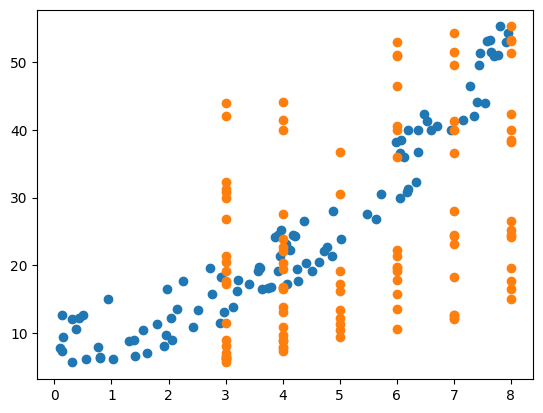

In [203]:
plt.scatter(marks_df['time_study'],marks_df['Marks'])
plt.scatter(marks_df['number_courses'],marks_df['Marks'])

### There is linear graph between Study Time and Marks But not with courses

In [204]:
x=marks_df[['time_study']]
y=marks_df['Marks']

In [207]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [208]:
x_train.shape

(80, 1)

In [209]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


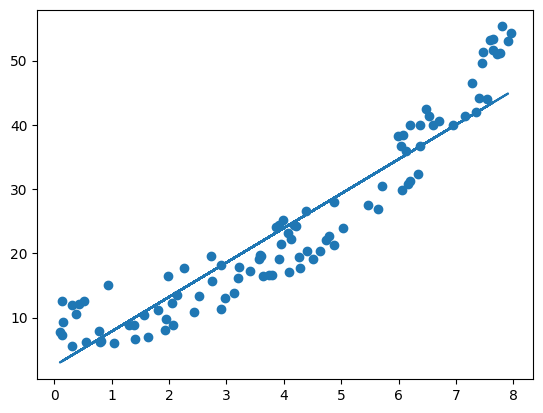

In [232]:
plt.scatter(x,y)
plt.plot(x_train,y_pred_train)

In [216]:
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [214]:
Slope=model.coef_
Intercept=model.intercept_
print(f" Slope or Co-efficient:{Slope}\n Intercept:{Intercept}")

 Slope or Co-efficient:[5.35532153]
 Intercept:2.5155655058073734


### 1 hour study increases marks by 5
### Zero hour study means 2.5 marks

In [219]:
error=y_train-y_pred_train

In [220]:
y_test-y_pred_test

83    -3.530528
53     1.743095
70    -5.917047
45    -4.628883
44    -3.237864
39     6.988810
22    -1.290330
80     9.193141
10     0.142755
0     -7.455355
18     7.175550
30     0.963472
73    -4.225384
33     2.136444
90    -0.517520
4     10.953018
76     0.068838
77     3.710835
12    -0.786312
31    -4.713849
Name: Marks, dtype: float64

In [ ]:
# R^2 
r_square_train=r2_score(y_train,y_pred_train)
r_square_test=r2_score(y_test,y_pred_test)
print(f" R-Square-Train:{r_square_train}\n R-Square-Test:{r_square_test}")


 R-Square-Train:0.8740104147945417
 R-Square-Test:0.9040228286990537


 * R^2 > 9 Good model

In [ ]:
# MAE
MAE_train = mean_absolute_error(y_train, y_pred_train)
MAE_test = mean_absolute_error(y_test,y_pred_test)

print("Train MAE =", MAE_train)
print("Test MAE =", MAE_test)


Train MAE = 3.9811994193693048
Test MAE = 3.9689515350594236


* Lower MAE is better

In [ ]:
# MSE 
MSE_train = mean_squared_error(y_train,y_pred_train)
MSE_test = mean_squared_error(y_test,y_pred_test)
print(f" MSE Train:{MSE_train}\n MSE Test:{MSE_test}")

 MSE Train:22.957504476389232
 MSE Test:25.23674562363223


In [230]:
# RMSE
RMSE_train=np.sqrt(MSE_train)
RMSE_test=np.sqrt(MSE_test)
print(f" RMSE Train:{RMSE_train}\n RMSE Test:{RMSE_test}")


 RMSE Train:4.791399010350655
 RMSE Test:5.023618777697232


* lower RMSE is better 